# Wright_2017 PISN models

The four PISN models described in the paper `Neutrino signal from pair-instability supernovae' by Wright et al., Phys. Rev. D96 (2017) 103008  <https://journals.aps.org/prd/abstract/10.1103/PhysRevD.96.103008>`

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('font', size=14)

import numpy as np

from astropy import units as u 

from snewpy.models.pisn import Wright_2017
from snewpy.flavor import ThreeFlavor
from snewpy.neutrino import MixingParameters
from snewpy.flavor_transformation import AdiabaticMSW

## A Function which plots the Initial and Oscillated Spectra using the Adiabatic MSW Flavor Transformation and the Normal mass ordering

Plot the neutrino spectra at the source and after the requested flavor transformation has been applied.

In [2]:
def plot_spectra(model, time=1*u.s):
    # Adiabatic MSW effect. NMO is used by default.
    xform_nmo = AdiabaticMSW(MixingParameters())

    # Energy array and time to compute spectra.
    # Note that any convenient units can be used and the calculation will remain internally consistent.
    E = np.linspace(0,100,201) * u.MeV

    ispec = model.get_initial_spectra(time, E)
    ospec_nmo = model.get_transformed_spectra(time, E, xform_nmo)

    fig, axes = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True, tight_layout=True)

    for i, spec in enumerate([ispec, ospec_nmo]):
        ax = axes[i]
        for flavor in ThreeFlavor:
            ax.plot(E, spec[flavor].array.squeeze(),
                   label=flavor.to_tex(),
                   color='C0' if flavor.is_electron else 'C1',
                   ls='-' if flavor.is_neutrino else ':', lw=2,
                   alpha=0.7)

        ax.set(xlabel=r'$E$ [{}]'.format(E.unit),
           title='Initial Spectra: $t = ${:.1f}'.format(time) if i==0 else 'Oscillated Spectra: $t = ${:.1f}'.format(time))
        ax.grid()
        ax.legend(loc='upper right', ncol=2, fontsize=16)

    ax = axes[0]
    ax.set(ylabel=r'neutrino spectra [erg$^{-1}$ s$^{-1}$]')

    fig.tight_layout();

## Look at what models are available

In [3]:
Wright_2017.param

{'progenitor_mass': <Quantity [150., 250.] solMass>, 'eos': ['SFHo', 'Helm']}

## Go through the models, plot the original spectra and transformed spectra at $t=1$ s.

### 150$M_{\odot}$ Progenitor, Helm EOS

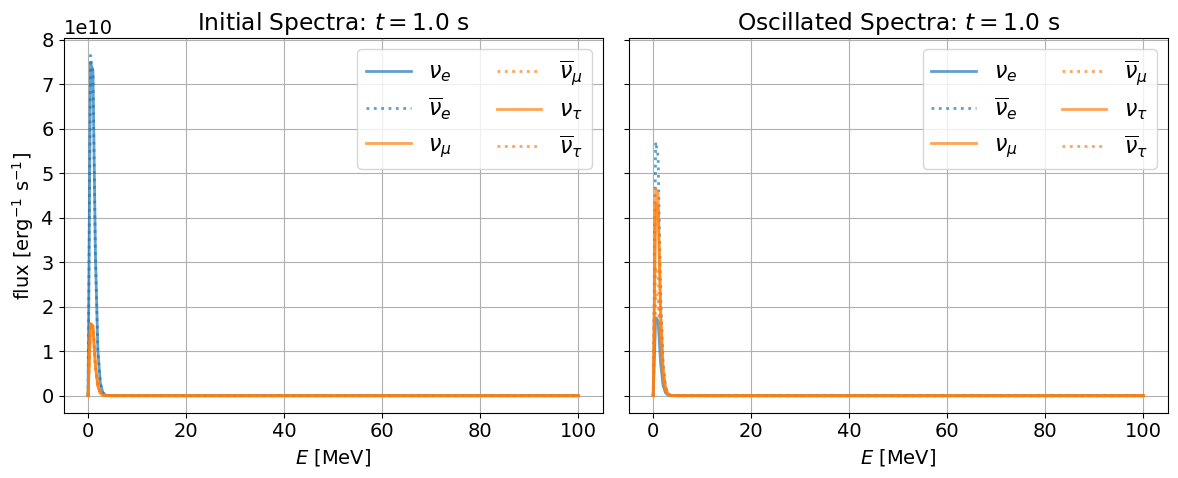

In [4]:
pisn1 = Wright_2017(progenitor_mass=150*u.solMass,eos='Helm')
fig = plot_spectra(pisn1, time=1*u.s)

### 150$M_\odot$ Progenitor, SFHo EOS

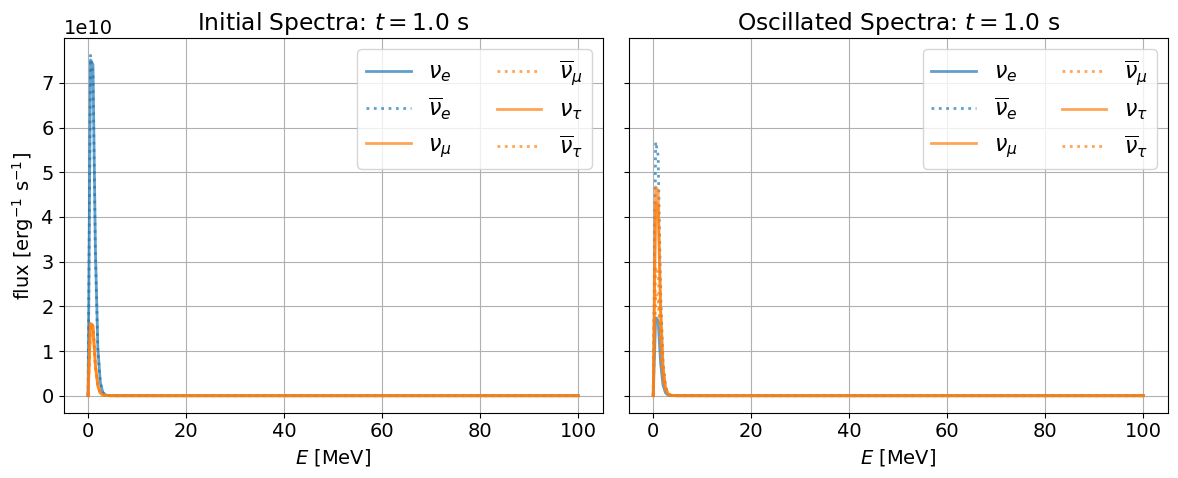

In [5]:
pisn2 = Wright_2017(progenitor_mass=150*u.solMass,eos='SFHo')
fig = plot_spectra(pisn2, time=1*u.s)

In [11]:
### 250$M_\odot$ Progenitor, Helm EOS

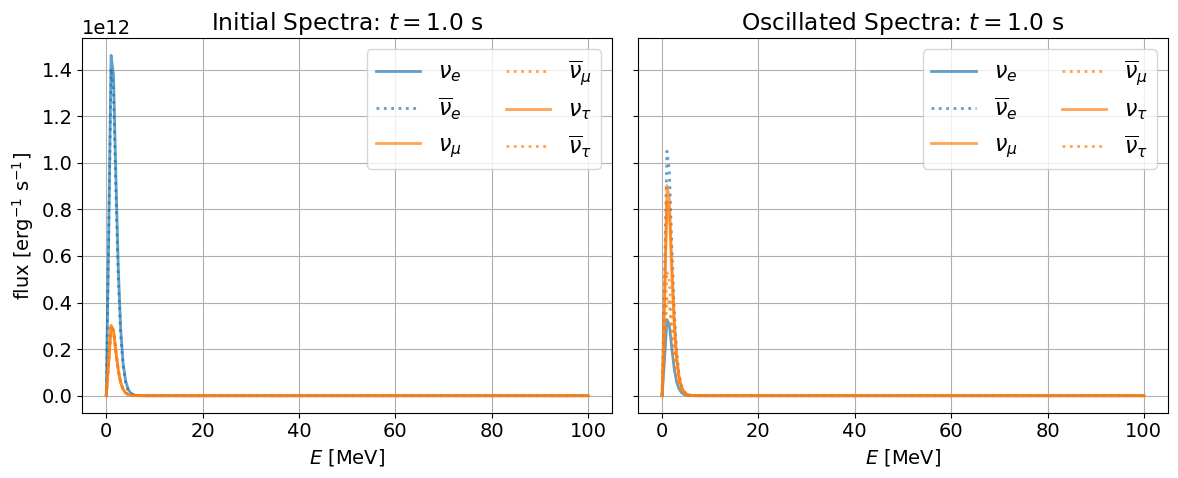

In [7]:
pisn3 = Wright_2017(progenitor_mass=250*u.solMass,eos='Helm')
fig = plot_spectra(pisn3, time=1*u.s)

### 250$M_\odot$ Progenitor, SFHo EOS

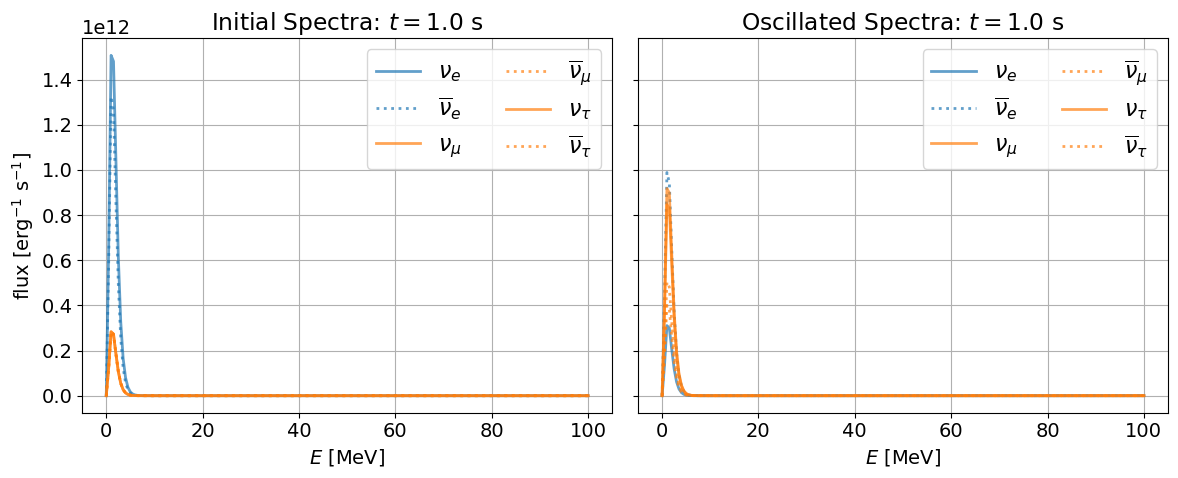

In [8]:
pisn4 = Wright_2017(progenitor_mass=250*u.solMass,eos='SFHo')
fig = plot_spectra(pisn4, time=1*u.s)